<a href="https://colab.research.google.com/github/marcolari06-maker/loan-default-prediction/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Acquiring

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import sklearn

github_csv_url = 'https://raw.githubusercontent.com/marcolari06-maker/loan-default-prediction/refs/heads/main/dataset.csv'

try:
    df_github = pd.read_csv(github_csv_url)
    print("Dataset loaded from github repo loan-default-prediction")
    display(df_github.head())
    print(df_github.shape[0])
except Exception as e:
    print(f"Error during loading from github: {e}")

Dataset loaded from github repo loan-default-prediction


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


148670


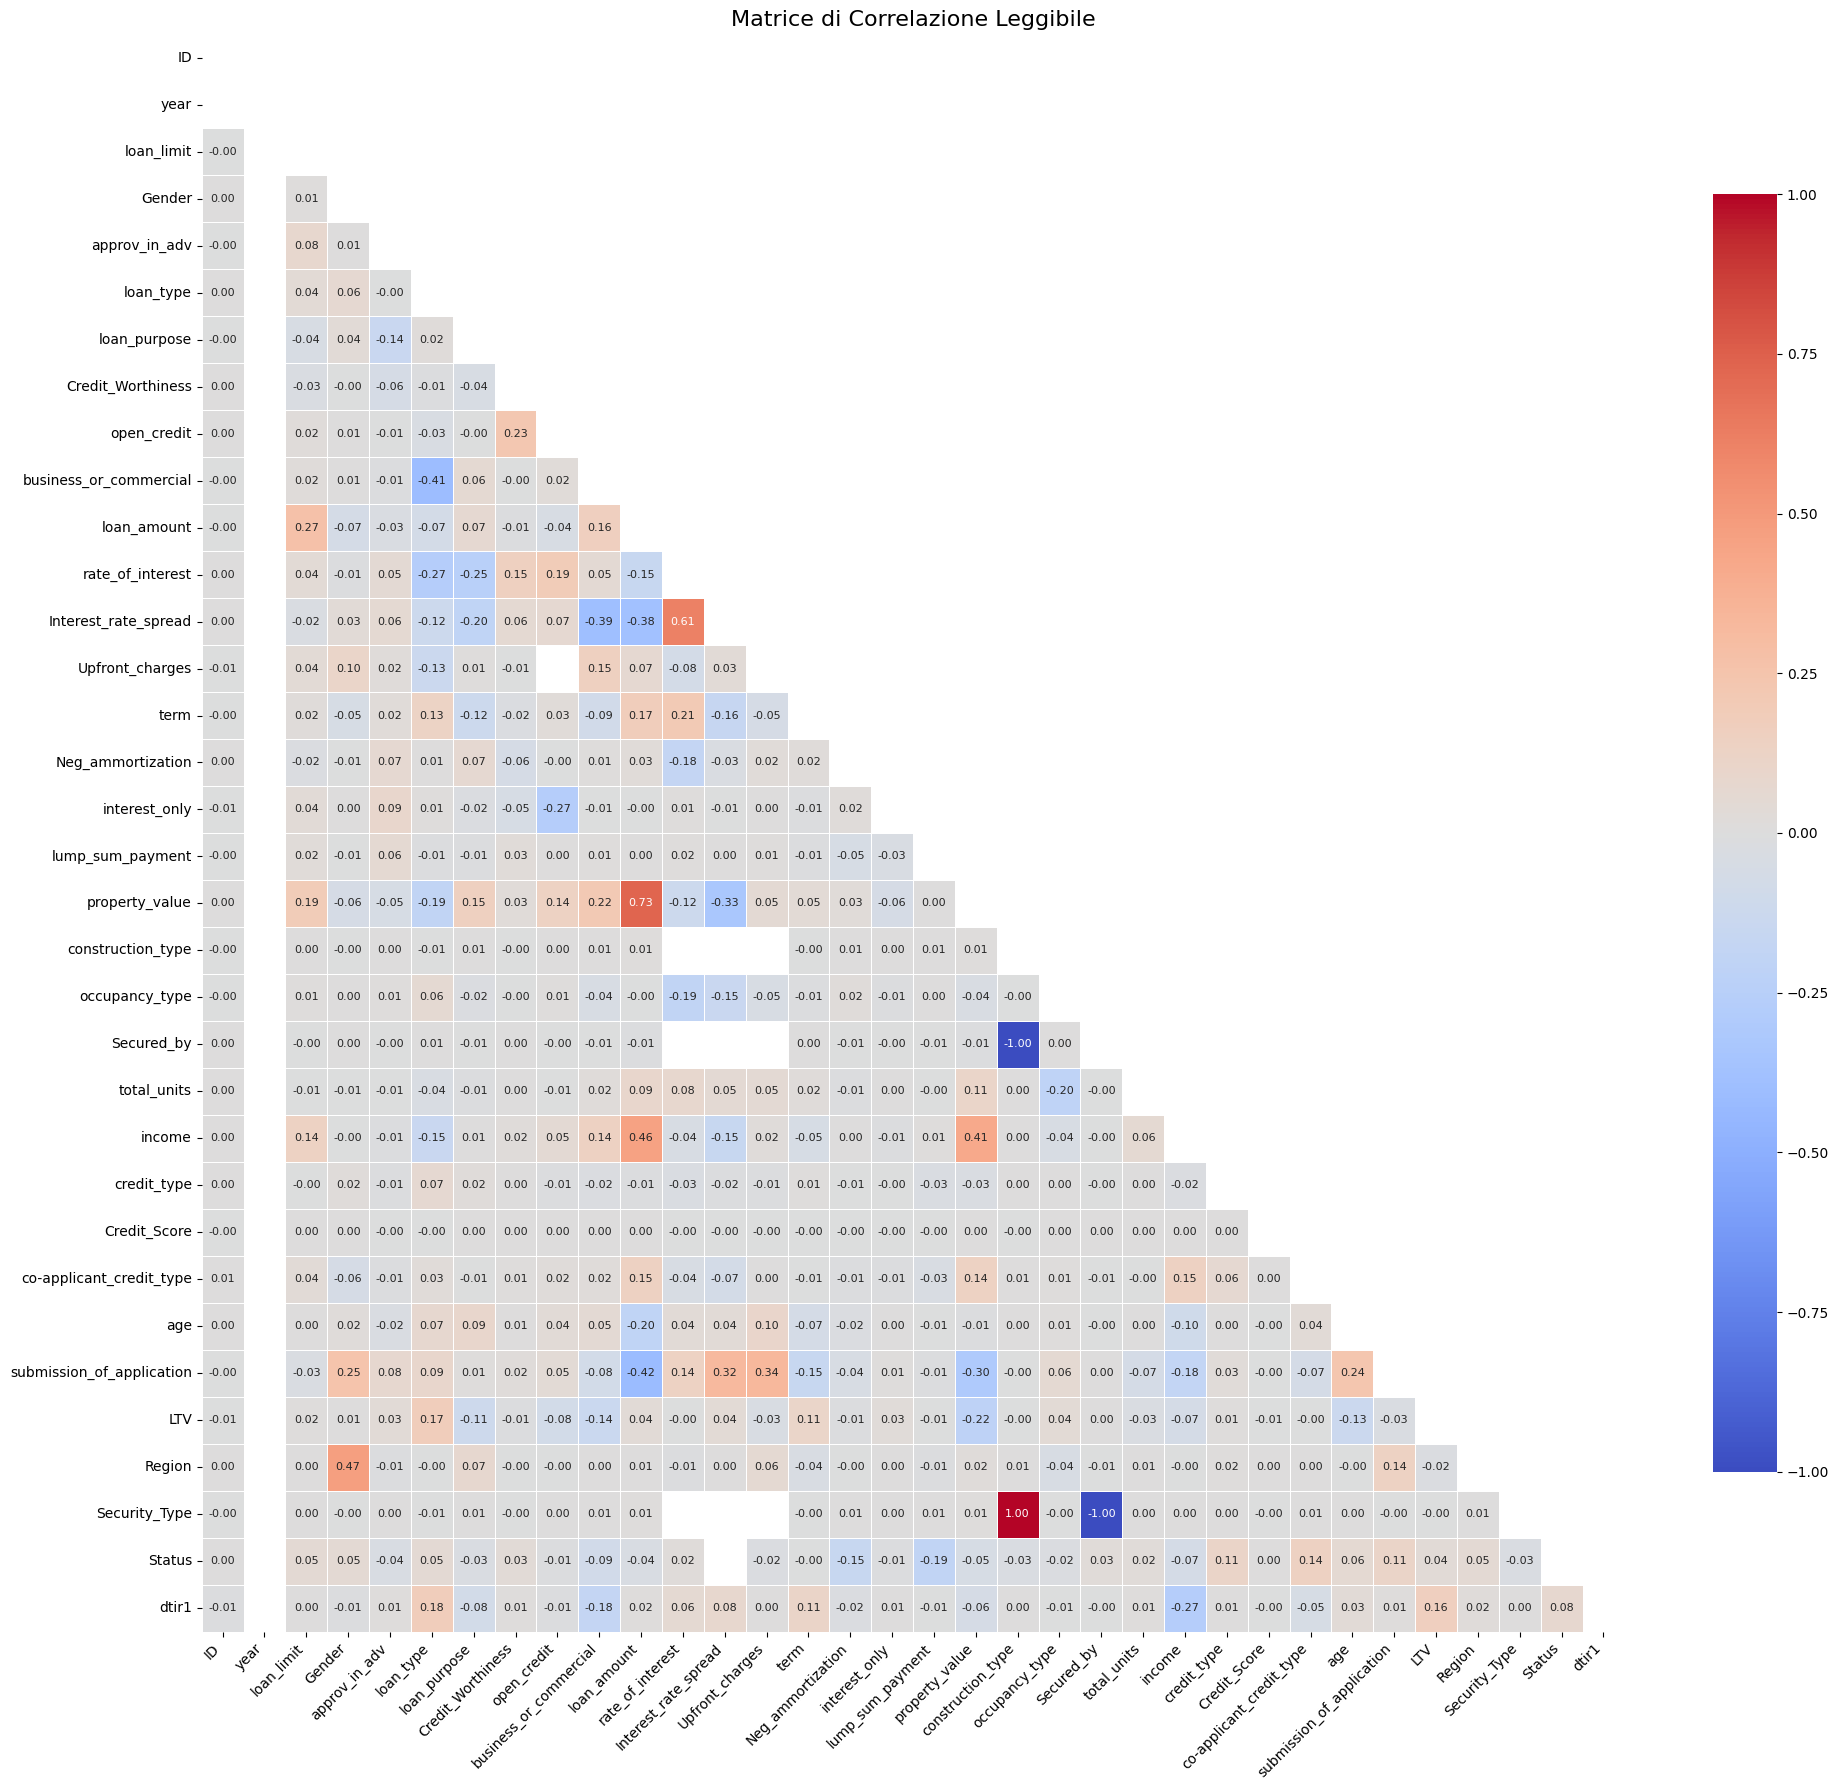

In [3]:
import numpy as np

df_encoded = df_github.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object' or df_encoded[col].dtype.name == 'category':
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr_matrix = df_encoded.corr(method='pearson')

# 1. Rendiamo la figura gigantesca (es. 20x18 pollici) così i quadrati si allargano
plt.figure(figsize=(20, 18))

# 2. Creiamo una maschera per nascondere la metà superiore (inutile perché speculare)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,           # Nasconde i duplicati
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1, vmax=1,
    annot_kws={"size": 8}, # <--- Rimpicciolisce il font dei numeri dentro i quadrati
    cbar_kws={"shrink": .8}
)

# Ruotiamo le etichette per non farle accavallare
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Matrice di Correlazione Leggibile", fontsize=16)
plt.tight_layout()
plt.show()

# Preprocessing

In this preliminar phase we modify directly the dataset to remove/changes features, where it wouldn't result in data leakage.

The operations applied are:

*   Removal of ID since is useless
*   Removal of year, all values are the same
*   Removal of Upfront charges (Data leakage)
*   Removal of Interest rate spread (Data leakage)
*   Removal of rate of interest (Data leakage)
*   Removal of Property value and LTV, both have the negative class that is too precise and removing the records would result in the loss of too many negative record, hence the column will be removed
*   Adding of unknown class to Loan limit
*   Removal of records with null values for Age, Submission of application, Loan purpose, Neg ammortization, Term
*   Check for duplicate rows
*   Redundancies addressing



In [4]:
# REMOVAL OF FEATURES
columns_to_drop = ['Upfront_charges', 'rate_of_interest', 'Interest_rate_spread'
                  , 'property_value', 'LTV', 'ID', 'year']

for col in columns_to_drop:
    if col in df_github.columns:
        df_github = df_github.drop(columns=[col])
        print(f"Column '{col}' dropped successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

# INSERTING UNKNOWN CLASS IN LOAN LIMIT
df_github['loan_limit'] = df_github['loan_limit'].fillna('Non_definito')
print("Loan limit after the operation")
print(df_github['loan_limit'].value_counts(dropna=False))

#REMOVAL OF RECORDS WITH NULL VALUES
interested_features = ['age', 'submission_of_application', 'loan_purpose', 'Neg_ammortization', 'term']
rows = df_github.shape[0]

for feat in interested_features:
    if feat in df_github.columns:
        df_github.dropna(subset=[feat], inplace=True)
        print(f"Rows dropped for {feat}: {rows - df_github.shape[0]}")
        rows = df_github.shape[0]
    else:
        print(f"Column '{feat}' not found. Skipping operation.")

# CHECK FOR DUPLICATE ROWS
duplicate_rows = df_github.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    # Optionally, display the duplicate rows
    # display(df_github[df_github.duplicated(keep=False)]) # keep=False shows all occurrences of duplicates
else:
    print("No duplicate rows found in the DataFrame.")

#REDUNDANCIES ADDRESSING
columns_to_remove = ['construction_type', 'Security_Type']

for col in columns_to_remove:
    if col in df_github.columns:
        df_github = df_github.drop(columns=[col])
        print(f"Column '{col}' removed successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

missing = df_github.isnull().sum()
missing_pct = (missing / len(df_github) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Mostra solo le colonne che hanno almeno 1 NaN
print(missing_df[missing_df['Missing Values'] > 0])

Column 'Upfront_charges' dropped successfully.
Column 'rate_of_interest' dropped successfully.
Column 'Interest_rate_spread' dropped successfully.
Column 'property_value' dropped successfully.
Column 'LTV' dropped successfully.
Column 'ID' dropped successfully.
Column 'year' dropped successfully.
Loan limit after the operation
loan_limit
cf              135348
ncf               9978
Non_definito      3344
Name: count, dtype: int64
Rows dropped for age: 200
Rows dropped for submission_of_application: 0
Rows dropped for loan_purpose: 126
Rows dropped for Neg_ammortization: 121
Rows dropped for term: 41
Number of duplicate rows found: 4
Column 'construction_type' removed successfully.
Column 'Security_Type' removed successfully.
               Missing Values  Missing %
dtir1                   23883      16.12
income                   8949       6.04
approv_in_adv             908       0.61


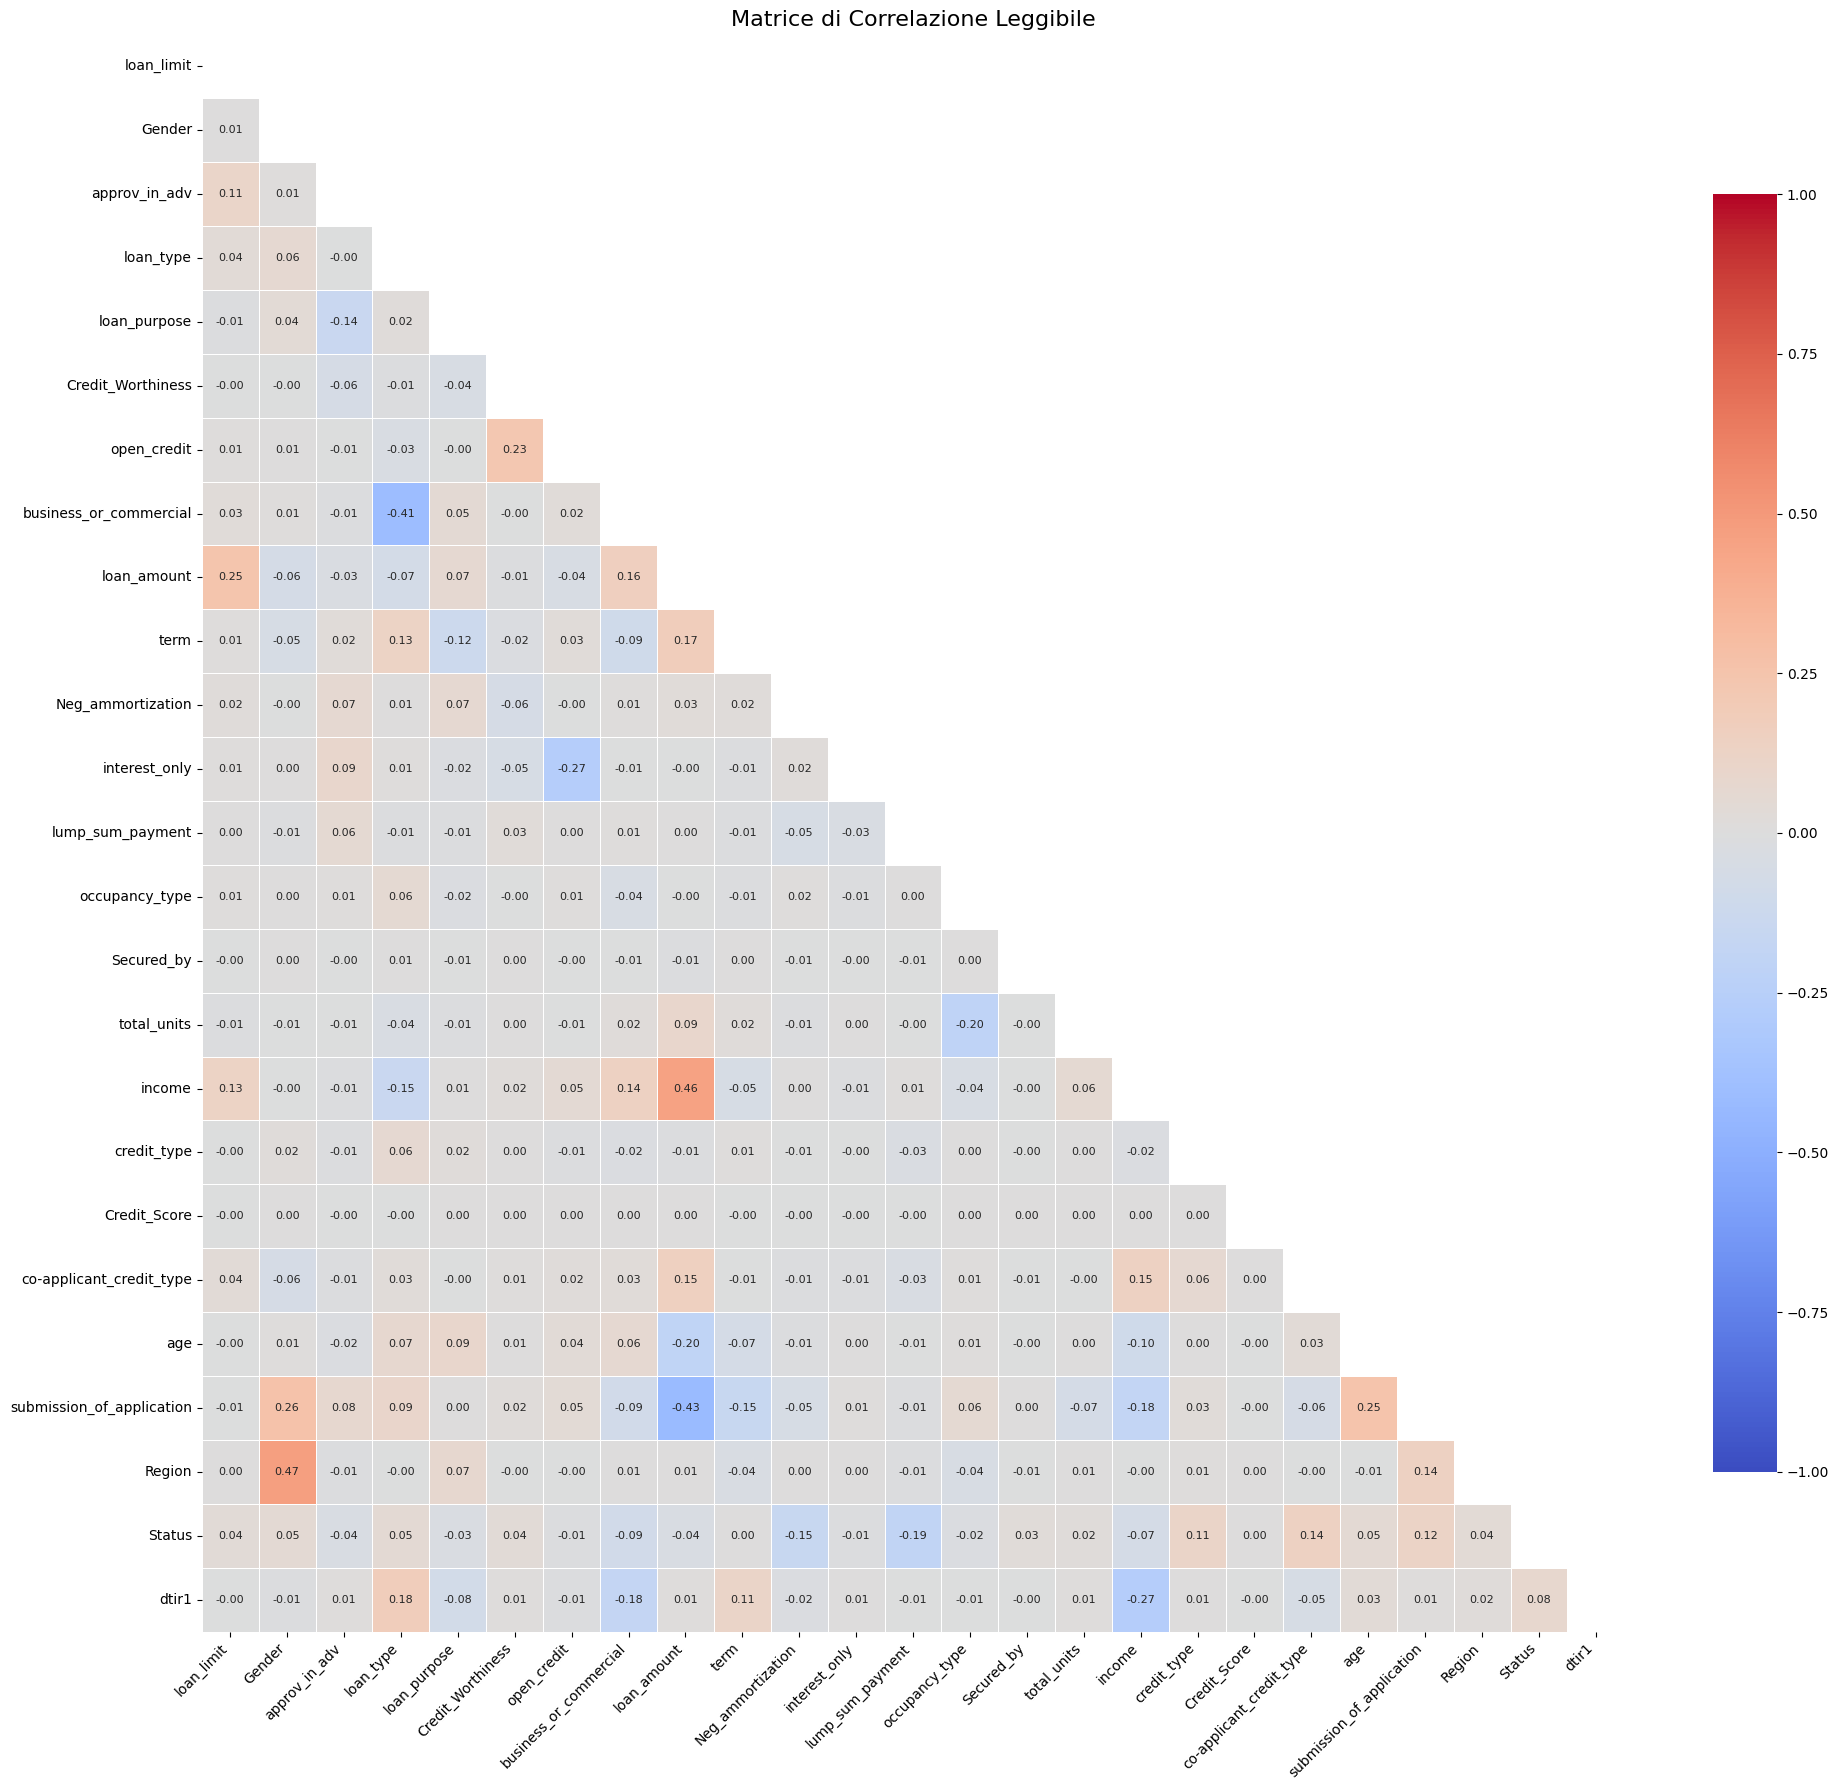

In [5]:
import numpy as np

df_encoded = df_github.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object' or df_encoded[col].dtype.name == 'category':
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr_matrix = df_encoded.corr(method='pearson')

# 1. Rendiamo la figura gigantesca (es. 20x18 pollici) così i quadrati si allargano
plt.figure(figsize=(20, 18))

# 2. Creiamo una maschera per nascondere la metà superiore (inutile perché speculare)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,           # Nasconde i duplicati
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1, vmax=1,
    annot_kws={"size": 8}, # <--- Rimpicciolisce il font dei numeri dentro i quadrati
    cbar_kws={"shrink": .8}
)

# Ruotiamo le etichette per non farle accavallare
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Matrice di Correlazione Leggibile", fontsize=16)
plt.tight_layout()
plt.show()

# Classification

## Initial setup

In [6]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    RandomizedSearchCV, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score

df = df_github.copy()
# --- feature / target ---
X = df.drop(columns=["Status"])
y = df["Status"]

num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:", num_features)
print("Categorical:", cat_features)

# --- preprocessore colonna per colonna ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   #IMPUTAZIONE MEDIANA
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  #IMPUTAZIONE MODA
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

# --- schemi di CV comuni ---
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# helper for eviting copy and paste
def nested_random_search(pipe, param_dist, n_iter=20, scoring="roc_auc"):
    rs = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=scoring,
        cv=inner_cv,
        n_jobs=-1,
        random_state=42,
        refit=True
    )
    nested_scores = cross_val_score(
        rs, X, y,
        cv=outer_cv,
        scoring=scoring,
        n_jobs=-1
    )
    return rs, nested_scores



Numerical: ['loan_amount', 'term', 'income', 'Credit_Score', 'dtir1']
Categorical: ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region']


## Logistic Regression

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform


pipe_lr = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        random_state=42
    ))
])

#WIDE RANDOM SEARCH
param_dist_lr = {
    "clf__C": loguniform(1e-4, 1e3),
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["lbfgs", "newton-cg", "saga"],
    "clf__max_iter": [500, 1000, 2000]
}

rs_lr, nested_scores_lr = nested_random_search(pipe_lr, param_dist_lr, n_iter=16) # 16 combinazioni bastano
print(f"LR nested AUC: {nested_scores_lr.mean():.3f} ± {nested_scores_lr.std():.3f}")

rs_lr.fit(X, y)
best_p_lr = rs_lr.best_params_

#SPECIFIC GRID SEARCH
best_c = best_p_lr["clf__C"]
param_grid_lr = {
    "clf__C":            [best_c * 0.2, best_c, best_c * 5],
    "clf__class_weight": [best_p_lr["clf__class_weight"]],
    "clf__penalty":      ["l2"],
    "clf__max_iter":      [best_p_lr["clf__max_iter"]],
    "clf__solver":       [best_p_lr["clf__solver"]]
}

gs_lr = GridSearchCV(
    pipe_lr,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)

gs_lr.fit(X, y)
best_lr = gs_lr.best_estimator_
print("LR best params:", gs_lr.best_params_)

#CROSS VALIDATION VALUTATION

y_pred_lr_cv = cross_val_predict(best_lr, X, y, cv=outer_cv, n_jobs=-1)

tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(y, y_pred_lr_cv).ravel()

fpr_lr = fp_lr / (fp_lr + tn_lr)
fnr_lr = fn_lr / (fn_lr + tp_lr)

print("\n" + "="*40)
print("  CONFUSION MATRIX - LOG RES")
print("="*40)
print(f"True Negative (TN): {tn_lr} \t False Positive (FP): {fp_lr}")
print(f"False Negative (FN): {fn_lr} \t True Positive (TP): {tp_lr}")
print("-"*40)
print(f"(FPR): {fpr_lr:.3%}")
print(f"(FNR): {fnr_lr:.3%}")
print("="*40)

LR nested AUC: 0.831 ± 0.003
LR best params: {'clf__C': np.float64(8.068170856795655), 'clf__class_weight': 'balanced', 'clf__max_iter': 2000, 'clf__penalty': 'l2', 'clf__solver': 'newton-cg'}

  CONFUSION MATRIX - LOG RES
True Negative (TN): 99001 	 False Positive (FP): 12816
False Negative (FN): 13540 	 True Positive (TP): 22825
----------------------------------------
(FPR): 11.462%
(FNR): 37.234%


## Naive bayes

Skeweness analysis

In [8]:
import matplotlib.pyplot as plt

print(X[num_features].skew().sort_values(ascending=False))

desc = X[num_features].describe().T[["mean", "50%"]]  # 50% = median
desc["mean_minus_median"] = desc["mean"] - desc["50%"]
print(desc.sort_values("mean_minus_median"))


income          17.333268
loan_amount      1.664427
Credit_Score     0.004948
dtir1           -0.551419
term            -2.172949
dtype: float64
                       mean       50%  mean_minus_median
term             335.120048     360.0         -24.879952
dtir1             37.732604      39.0          -1.267396
Credit_Score     699.766375     699.0           0.766375
income          6956.480145    5760.0        1196.480145
loan_amount   331287.558543  296500.0       34787.558543


In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import FunctionTransformer

# sposto 'term' da numerica a categorica (se presente)
if "term" in num_features:
    num_features.remove("term")
    if "term" not in cat_features:
        cat_features.append("term")

# variabili numeriche molto skewed
num_skewed = ["income", "loan_amount"]
num_skewed = [c for c in num_skewed if c in num_features]

# il resto delle numeriche
num_normal = [c for c in num_features if c not in num_skewed]

print("Num skewed:", num_skewed)
print("Num normal:", num_normal)
print("Cat (with term):", cat_features)

# per le numeriche skewed: mediana -> log1p -> scaler
numeric_skewed_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler()),
])

# per le altre numeriche: riuso il transformer generale
numeric_normal_transformer = numeric_transformer   # mediana + StandardScaler

# categoriche: MODIFICA PER GNB - OneHotEncoder deve produrre output denso
categorical_nb_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess_nb = ColumnTransformer(
    transformers=[
        ("num_skewed", numeric_skewed_transformer, num_skewed),
        ("num_normal", numeric_normal_transformer, num_normal),
        ("cat",        categorical_nb_transformer, cat_features),
    ]
)

pipe_nb = Pipeline(steps=[
    ("preprocess", preprocess_nb),
    ("clf", GaussianNB())
])

param_dist_nb = {
    "clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

rs_nb, nested_scores_nb = nested_random_search(
    pipe_nb,
    param_dist=param_dist_nb,
    n_iter=5,          # pochi parametri → pochi tentativi bastano
    scoring="roc_auc"
)

print(f"Naive Bayes nested AUC: {nested_scores_nb.mean():.3f} ± {nested_scores_nb.std():.3f}")

# rifinire intorno al best var_smoothing trovato da RS
rs_nb.fit(X, y)
best_vs = rs_nb.best_params_["clf__var_smoothing"]
print("RandomizedSearch best var_smoothing:", best_vs)

param_grid_nb = {
    "clf__var_smoothing": [best_vs / 10, best_vs, best_vs * 10]
}

gs_nb = GridSearchCV(
    pipe_nb,
    param_grid=param_grid_nb,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)

gs_nb.fit(X, y)
best_nb = gs_nb.best_estimator_
print("GridSearch best params (Naive Bayes):", gs_nb.best_params_)

Num skewed: ['income', 'loan_amount']
Num normal: ['Credit_Score', 'dtir1']
Cat (with term): ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'term']
Naive Bayes nested AUC: 0.811 ± 0.003
RandomizedSearch best var_smoothing: 1e-09
GridSearch best params (Naive Bayes): {'clf__var_smoothing': 1e-10}


## Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier

#PIPELINE PREPROCESS + CLASSIFIER
pipe_dt = Pipeline([
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(random_state=42))
])

#PARAMS
param_dist_dt = {
    "clf__max_depth":        [3, 5, 8, 10, 15, None],
    "clf__min_samples_leaf": [1, 5, 10, 20, 50],
    "clf__criterion":        ["gini", "entropy"],
    "clf__class_weight":     [None, "balanced"],
}

rs_dt, nested_scores_dt = nested_random_search(pipe_dt, param_dist_dt, n_iter=30)
print(f"DT nested AUC: {nested_scores_dt.mean():.3f} ± {nested_scores_dt.std():.3f}")

param_grid_dt = {
    "clf__max_depth":        [3, 5, 8],
    "clf__min_samples_leaf": [5, 10, 20],
    "clf__class_weight":     [None, "balanced"],
}

gs_dt = GridSearchCV(
    pipe_dt,
    param_grid=param_grid_dt,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)
gs_dt.fit(X, y)
best_dt = gs_dt.best_estimator_
print("DT best params:", gs_dt.best_params_)

#CROSS VALIDATION VALUTATION

y_pred_dt_cv = cross_val_predict(best_dt, X, y, cv=outer_cv, n_jobs=-1)

tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(y, y_pred_dt_cv).ravel()

fpr_lr = fp_lr / (fp_lr + tn_lr)
fnr_lr = fn_lr / (fn_lr + tp_lr)

print("\n" + "="*40)
print("  CONFUSION MATRIX - LOG RES")
print("="*40)
print(f"True Negative (TN): {tn_lr} \t False Positive (FP): {fp_lr}")
print(f"False Negative (FN): {fn_lr} \t True Positive (TP): {tp_lr}")
print("-"*40)
print(f"(FPR): {fpr_lr:.3%}")
print(f"(FNR): {fnr_lr:.3%}")
print("="*40)


DT nested AUC: 0.862 ± 0.002
DT best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 8, 'clf__min_samples_leaf': 20}

  CONFUSION MATRIX - LOG RES
True Negative (TN): 99768 	 False Positive (FP): 12049
False Negative (FN): 11580 	 True Positive (TP): 24785
----------------------------------------
(FPR): 10.776%
(FNR): 31.844%


## Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# provare ad aumentare spazio, in questo modo ci mette sui 3 minuti
param_dist_rf = {
    "clf__n_estimators":     [50, 100],
    "clf__max_depth":        [10, None],
    "clf__min_samples_leaf": [10, 20],
    "clf__max_features":     ["sqrt", "log2", 0.3],
    "clf__class_weight":     [None, "balanced"],
}

rs_rf, nested_scores_rf = nested_random_search(pipe_rf, param_dist_rf, n_iter=15)
print(f"RF nested AUC: {nested_scores_rf.mean():.3f} ± {nested_scores_rf.std():.3f}")

# usa i best params del RandomizedSearch come centro del grid
rs_rf.fit(X, y)
best_p_rf = rs_rf.best_params_

param_grid_rf = {
    "clf__n_estimators": [best_p_rf["clf__n_estimators"]],
    "clf__max_depth":    [best_p_rf["clf__max_depth"]],
    "clf__min_samples_leaf": [
        max(1, best_p_rf["clf__min_samples_leaf"] - 5),
        best_p_rf["clf__min_samples_leaf"],
        best_p_rf["clf__min_samples_leaf"] + 5
    ],
    "clf__class_weight": [best_p_rf["clf__class_weight"]],
}

gs_rf = GridSearchCV(
    pipe_rf,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)
gs_rf.fit(X, y)
best_rf = gs_rf.best_estimator_

print("RF best params:", gs_rf.best_params_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RF nested AUC: 0.873 ± 0.001
RF best params: {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}


## Adaboost

In [14]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

pipe_ada = Pipeline([
    ("preprocess", preprocess),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        random_state=42
    ))
])

#spazio piccolo, valutiamo di mettere solamente gridsearch o se possibile
# aumentare sazio di ricerca
param_dist_ada = {
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
}

rs_ada, nested_scores_ada = nested_random_search(
    pipe_ada, param_dist_ada, n_iter=20
)
print(f"AdaBoost nested AUC: {nested_scores_ada.mean():.3f} ± {nested_scores_ada.std():.3f}")


rs_ada.fit(X, y)
best_p_ada = rs_ada.best_params_

param_grid_ada = {
    "clf__n_estimators": [best_p_ada["clf__n_estimators"]],
    "clf__learning_rate": [
        best_p_ada["clf__learning_rate"] / 2,
        best_p_ada["clf__learning_rate"],
        best_p_ada["clf__learning_rate"] * 2
    ]
}

gs_ada = GridSearchCV(
    pipe_ada,
    param_grid=param_grid_ada,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)
gs_ada.fit(X, y)
best_ada = gs_ada.best_estimator_
print("GB best params:", gs_ada.best_params_)

AdaBoost nested AUC: 0.843 ± 0.003


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=20. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


GB best params: {'clf__learning_rate': 1.0, 'clf__n_estimators': 200}


## Comparison

In [ ]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    make_scorer, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

summary_nested = pd.DataFrame({
    "model": ["LogReg", "DecTree", "RandomForest", "AdaBoost", "NaiveBayes"],
    "nested_auc_mean": [
        nested_scores_lr.mean(),
        nested_scores_dt.mean(),
        nested_scores_rf.mean(),
        nested_scores_ada.mean(),
        nested_scores_nb.mean()
    ],
    "nested_auc_std": [
        nested_scores_lr.std(),
        nested_scores_dt.std(),
        nested_scores_rf.std(),
        nested_scores_ada.std(),
        nested_scores_nb.std()
    ],
})

print(summary_nested.sort_values("nested_auc_mean", ascending=False))

models_final = [
    ("LogReg",       best_lr),
    ("DecTree",      best_dt),
    ("RandomForest", best_rf),
    ("AdaBoost",    best_ada),
    ("NaiveBayes",   best_nb)
]

rows = []
y_preds = {}

for name, clf in models_final:

    y_pred_oof = cross_val_predict(
        clf, X, y,
        cv=outer_cv,
        n_jobs=2 # Changed from -1 to 2
    )
    y_preds[name] = y_pred_oof
    # AUC media in CV
    auc_scores = cross_val_score(
        clf, X, y,
        cv=outer_cv,
        scoring="roc_auc",
        n_jobs=2 # Changed from -1 to 2
    )
    # F1 media sulla classe positiva (default=1)
    f1_scores = cross_val_score(
        clf, X, y,
        cv=outer_cv,
        scoring="f1",   # per binary {0,1} usa F1 su 1
        n_jobs=2 # Changed from -1 to 2
    )
    # Precision media sulla classe positiva
    precision_scores = cross_val_score(
        clf, X, y,
        cv=outer_cv,
        scoring="precision",
        n_jobs=2 # Changed from -1 to 2
    )
    # Recall media sulla classe positiva
    recall_scores = cross_val_score(
        clf, X, y,
        cv=outer_cv,
        scoring="recall",
        n_jobs=2 # Changed from -1 to 2
    )
    rows.append({
        "model":      name,
        "auc_mean":   auc_scores.mean(),
        "auc_std":    auc_scores.std(),
        "f1_mean":    f1_scores.mean(),
        "f1_std":     f1_scores.std(),
        "precision_mean": precision_scores.mean(),
        "precision_std":  precision_scores.std(),
        "recall_mean":    recall_scores.mean(),
        "recall_std":     recall_scores.std(),
    })

df_metrics = pd.DataFrame(rows)
print(df_metrics.sort_values("auc_mean", ascending=False))

plt.figure(figsize=(6, 4))
plt.scatter(df_metrics["auc_mean"], df_metrics["f1_mean"])

for _, r in df_metrics.iterrows():
    plt.text(
        r["auc_mean"] + 0.001,
        r["f1_mean"] + 0.001,
        r["model"]
    )

plt.xlabel("ROC-AUC (media CV)")
plt.ylabel("F1 classe default (media CV)")
plt.title("Confronto modelli nel piano AUC–F1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Confusion Matrices (predizioni OOF, outer CV) ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Confusion Matrix per modello (Out-of-Fold, outer CV)", fontsize=13)

for ax, (name, clf) in zip(axes, models_final):
    cm = confusion_matrix(y, y_preds[name])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non default (0)", "Default (1)"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predetto")
    ax.set_ylabel("Reale")

plt.tight_layout()
plt.show()

          model  nested_auc_mean  nested_auc_std
2  RandomForest         0.873481        0.001341
1       DecTree         0.862167        0.002404
3      AdaBoost         0.843152        0.002639
0        LogReg         0.830526        0.002505
4    NaiveBayes         0.810596        0.002714
